# Smoking Landmark Preprocessing & Visualization

Notebook này phân tích `smoking_landmarks.csv` và `smoking_landmarks_binary.csv`.

Mục tiêu:
- Kiểm tra dữ liệu smoking gốc và binary.
- Trực quan landmark mặt trước/sau normalize.
- Vẽ proxy vùng miệng/cằm để xem smoking có dấu hiệu hình học không.
- PCA + confusion matrix train nhanh cho binary smoking/no_smoking.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 30)

In [2]:
NOTEBOOK_DIR = Path.cwd()
DATA_DIR_CANDIDATES = [
    NOTEBOOK_DIR / ".." / "collect" / "data",
    Path("../collect/data"),
    Path("DiQuaMuaHaa/backend/driver_training/collect/data"),
]
DATA_DIR = next((p.resolve() for p in DATA_DIR_CANDIDATES if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Không tìm thấy collect/data")

smoking_csv = DATA_DIR / "smoking_landmarks.csv"
binary_csv = DATA_DIR / "smoking_landmarks_binary.csv"
OUT_DIR = (NOTEBOOK_DIR / "outputs" / "smoking").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
smoking_csv, binary_csv, OUT_DIR

(WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend/driver_training/collect/data/smoking_landmarks.csv'),
 WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend/driver_training/collect/data/smoking_landmarks_binary.csv'),
 WindowsPath('D:/deployweb/conghienmegrge/DiQuaMuaHaa/backend/driver_training/analysis/outputs/smoking'))

In [3]:
def load_landmark_csv(path):
    df = pd.read_csv(path, header=None)
    y = df.iloc[:, 0].astype(str)
    X = df.iloc[:, 1:].astype("float32")
    return df, y, X

datasets = {}
for name, path in [("smoking_only", smoking_csv), ("binary", binary_csv)]:
    if path.exists():
        datasets[name] = load_landmark_csv(path)
        print(name, path)
        print(datasets[name][1].value_counts())
    else:
        print(name, "missing", path)

if "binary" not in datasets:
    raise FileNotFoundError("Cần smoking_landmarks_binary.csv để train/eval binary.")

labels = datasets["binary"][1]
X_raw = datasets["binary"][2]
n_samples, n_features = X_raw.shape
n_landmarks = n_features // 3
print("binary shape:", X_raw.shape, "landmarks:", n_landmarks)
if n_features % 3 != 0:
    warnings.warn("Feature count không chia hết cho 3.")

smoking_only D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\driver_training\collect\data\smoking_landmarks.csv
0
smoking    593
Name: count, dtype: int64
binary D:\deployweb\conghienmegrge\DiQuaMuaHaa\backend\driver_training\collect\data\smoking_landmarks_binary.csv
0
smoking       593
no_smoking    593
Name: count, dtype: int64
binary shape: (1186, 1434) landmarks: 478


## 1. Class balance và feature range

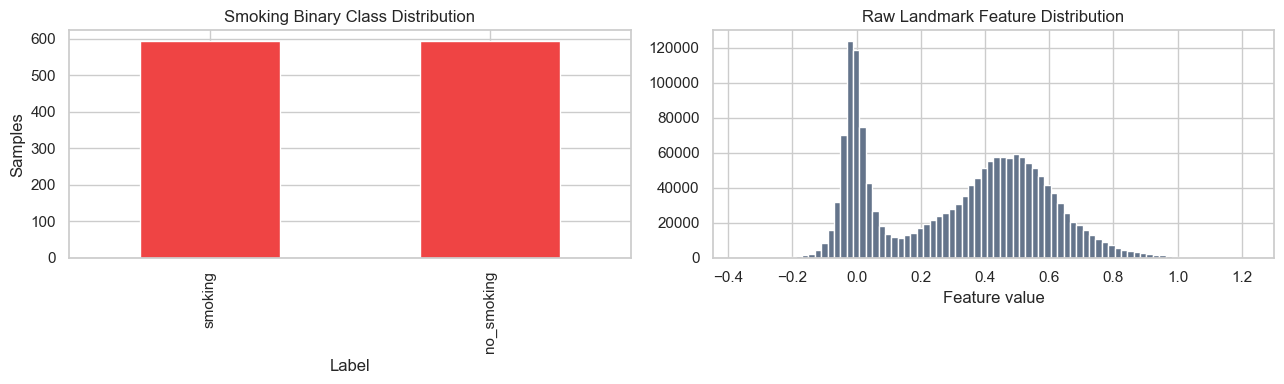

,missing,min,max,mean,std
0,0,-0.368498,1.220698,0.314241,0.260857


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels.value_counts().plot(kind="bar", ax=axes[0], color="#ef4444")
axes[0].set_title("Smoking Binary Class Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Samples")

axes[1].hist(X_raw.to_numpy().ravel(), bins=80, color="#64748b")
axes[1].set_title("Raw Landmark Feature Distribution")
axes[1].set_xlabel("Feature value")
plt.tight_layout()
fig.savefig(OUT_DIR / "01_class_feature_distribution.png", dpi=160)
plt.show()

display(pd.DataFrame({
    "missing": [int(X_raw.isna().sum().sum())],
    "min": [float(X_raw.min().min())],
    "max": [float(X_raw.max().max())],
    "mean": [float(X_raw.to_numpy().mean())],
    "std": [float(X_raw.to_numpy().std())],
}))

## 2. Preprocessing: normalize face landmarks

Dùng midpoint hai mắt làm tâm và khoảng cách hai mắt làm scale. Đây là cùng tinh thần với notebook face.

In [5]:
L_EYE_OUTER = 33
R_EYE_OUTER = 263
MOUTH_UPPER = 13
MOUTH_LOWER = 14
MOUTH_LEFT = 61
MOUTH_RIGHT = 291
CHIN = 152
NOSE = 1

def to_points(row):
    return np.asarray(row, dtype=np.float32).reshape(-1, 3)

def dist(a, b):
    return float(np.linalg.norm(np.asarray(a[:2]) - np.asarray(b[:2])))

def normalize_face(points):
    points = np.asarray(points, dtype=np.float32).reshape(-1, 3)
    center = (points[L_EYE_OUTER] + points[R_EYE_OUTER]) / 2.0
    scale = dist(points[L_EYE_OUTER], points[R_EYE_OUTER])
    if not np.isfinite(scale) or scale < 1e-6:
        scale = 1.0
    return ((points - center) / scale).astype(np.float32)

def compute_mar(points):
    return dist(points[MOUTH_UPPER], points[MOUTH_LOWER]) / (dist(points[MOUTH_LEFT], points[MOUTH_RIGHT]) + 1e-6)

def mouth_to_chin(points):
    mouth_mid = (points[MOUTH_UPPER] + points[MOUTH_LOWER]) / 2.0
    return dist(mouth_mid, points[CHIN])

def nose_to_mouth(points):
    mouth_mid = (points[MOUTH_LEFT] + points[MOUTH_RIGHT]) / 2.0
    return dist(points[NOSE], mouth_mid)

points_raw = np.stack([to_points(r) for r in X_raw.to_numpy()])
points_norm = np.stack([normalize_face(p) for p in points_raw])
X_norm = points_norm.reshape(len(points_norm), -1)
points_raw.shape, X_norm.shape

((1186, 478, 3), (1186, 1434))

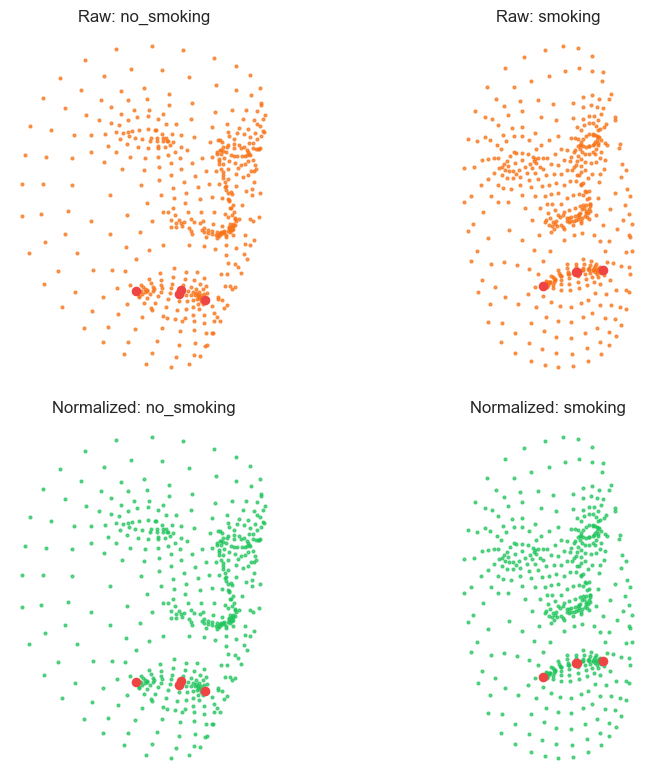

In [6]:
def plot_face(points, ax=None, title="", color="#06b6d4"):
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))
    ax.scatter(points[:, 0], -points[:, 1], s=4, alpha=0.7, c=color)
    mouth_ids = [MOUTH_LEFT, MOUTH_UPPER, MOUTH_RIGHT, MOUTH_LOWER]
    ax.scatter(points[mouth_ids, 0], -points[mouth_ids, 1], s=35, c="#ef4444")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.axis("off")
    return ax

unique_labels = sorted(labels.unique())
fig, axes = plt.subplots(2, len(unique_labels), figsize=(5 * len(unique_labels), 8))
if len(unique_labels) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for col, label in enumerate(unique_labels):
    idx = labels[labels == label].index[0]
    plot_face(points_raw[idx], axes[0, col], f"Raw: {label}", "#f97316")
    plot_face(points_norm[idx], axes[1, col], f"Normalized: {label}", "#22c55e")
plt.tight_layout()
fig.savefig(OUT_DIR / "02_smoking_before_after_normalize.png", dpi=160)
plt.show()

## 3. Metric proxy vùng miệng

Smoking bằng landmark mặt thường khó hơn ngáp, vì điếu thuốc/vật thể không phải lúc nào cũng nằm trong landmark. Các metric dưới đây chỉ để soi data, không nên coi là rule cuối cùng.

MAR                                                         \
            count    mean    std     min     25%     50%     75%     max   
label                                                                      
no_smoking  593.0  0.2385  0.356  0.0004  0.0094  0.0583  0.3462  1.6356   
smoking     593.0  0.0985  0.152  0.0002  0.0091  0.0323  0.1198  1.0615   

           mouth_to_chin                                                  \
                   count    mean     std     min     25%     50%     75%   
label                                                                      
no_smoking         593.0  0.5282  0.1417  0.2223  0.4324  0.5100  0.6229   
smoking            593.0  0.6686  0.2774  0.2031  0.4280  0.6474  0.8614   

                   nose_to_mouth                                          \
               max         count    mean     std     min     25%     50%   
label                                                                      
no_smoking  1.1342         593.0  0.4570  0.1860  0.0279  0.3092  0.4387   
smoking     1.9685         593.0  0.5325  0.2486  0.1062  0.3322  0.5108   

                            
               75%     max  
label                       
no_smoking  0.5993  0.9933  
smoking     0.6708  1.6441

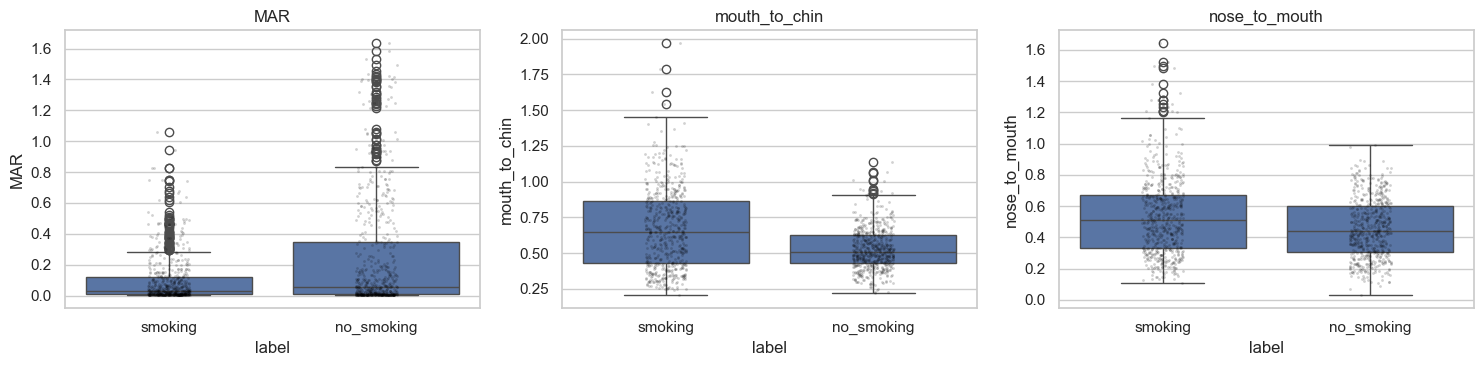

In [7]:
metrics = pd.DataFrame({
    "label": labels.values,
    "MAR": [compute_mar(p) for p in points_raw],
    "mouth_to_chin": [mouth_to_chin(p) for p in points_norm],
    "nose_to_mouth": [nose_to_mouth(p) for p in points_norm],
})
display(metrics.groupby("label").describe().round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["MAR", "mouth_to_chin", "nose_to_mouth"]):
    if sns:
        sns.boxplot(data=metrics, x="label", y=col, ax=ax)
        sns.stripplot(data=metrics, x="label", y=col, ax=ax, color="black", alpha=0.18, size=2)
    else:
        metrics.boxplot(column=col, by="label", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
fig.savefig(OUT_DIR / "03_smoking_mouth_proxy_metrics.png", dpi=160)
plt.show()

## 4. PCA và confusion matrix

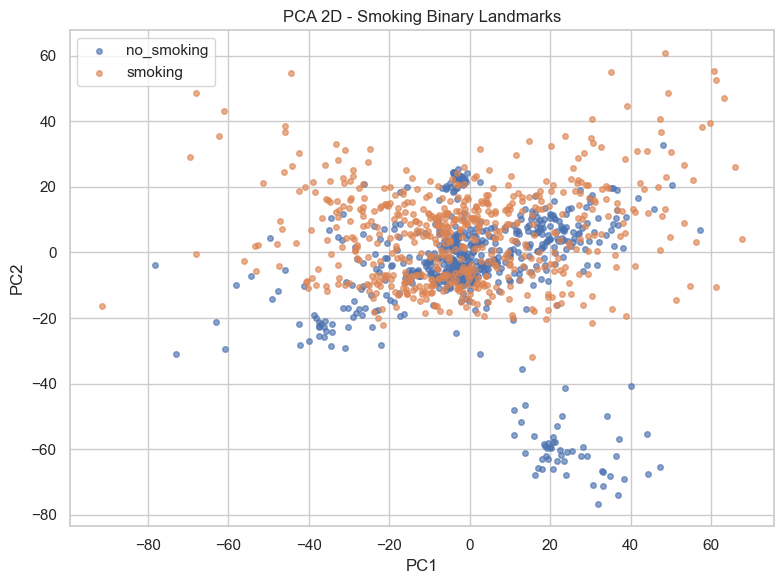

In [8]:
Xs = StandardScaler().fit_transform(X_norm)
pca = PCA(n_components=2, random_state=42).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(8, 6))
for label in unique_labels:
    mask = labels.values == label
    ax.scatter(pca[mask, 0], pca[mask, 1], s=16, alpha=0.65, label=label)
ax.set_title("PCA 2D - Smoking Binary Landmarks")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "04_pca_smoking_binary.png", dpi=160)
plt.show()

              precision    recall  f1-score   support

  no_smoking      0.894     0.924     0.909       119
     smoking      0.922     0.891     0.906       119

    accuracy                          0.908       238
   macro avg      0.908     0.908     0.908       238
weighted avg      0.908     0.908     0.908       238



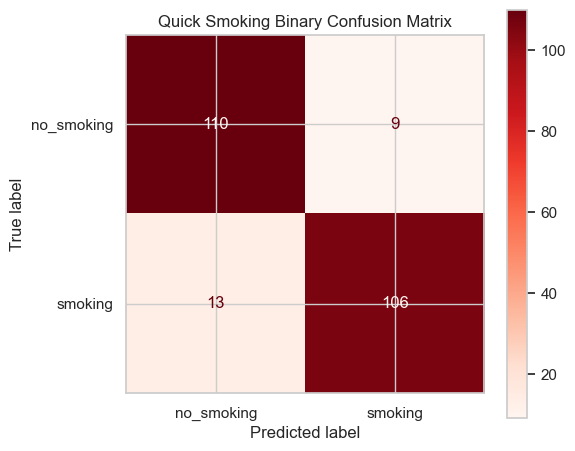

In [9]:
stratify = labels.values if labels.value_counts().min() >= 2 else None
X_train, X_val, y_train, y_val = train_test_split(X_norm, labels.values, test_size=0.2, random_state=42, stratify=stratify)
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)),
])
model.fit(X_train, y_train)
pred = model.predict(X_val)
print(classification_report(y_val, pred, digits=3))

cm_labels = sorted(labels.unique())
cm = confusion_matrix(y_val, pred, labels=cm_labels)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=cm_labels).plot(ax=ax, cmap="Reds", values_format="d")
ax.set_title("Quick Smoking Binary Confusion Matrix")
plt.tight_layout()
fig.savefig(OUT_DIR / "05_confusion_matrix_smoking.png", dpi=160)
plt.show()

## Ghi chú

Nếu smoking model chỉ dựa landmark mặt thì sẽ yếu khi điếu thuốc nằm ngoài vùng mặt hoặc bị tay che. Nếu có ảnh/bbox điếu thuốc, nên ưu tiên object detection hoặc thêm crop quanh miệng/tay.